In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns

In [2]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

fatal: destination path 'PRMLProject' already exists and is not an empty directory.
/content/PRMLProject


In [3]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [4]:
X_train_knn_res=unpickle("PreProcessedData/Resnet_train.pkl")
X_train_knn_res = np.array(X_train_knn_res)
print(X_train_knn_res.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_res=unpickle("PreProcessedData/Resnet_test.pkl")
X_test_knn_res = np.array(X_test_knn_res)
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 2048)
(50000,)


Writing our own KNN Implementation

In [5]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_knn(k=10, X_train=X_train_knn_res, X_test=X_test_knn_res, y_train=y_train, y_test=y_test):
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Compute distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, results)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

100%|██████████| 10000/10000 [1:04:04<00:00,  2.60it/s]


Accuracy: 85.25%
Confusion Matrix:
 [[854  17   6   8   6   0   5   2  68  34]
 [ 10 926   1   5   0   0   1   2   6  49]
 [ 43   1 735  51  72  11  69   9   9   0]
 [  5   3  16 776  41  77  49  19   5   9]
 [ 14   2   9  33 826   5  58  48   3   2]
 [  5   2   9 120  27 796  11  26   1   3]
 [  5   3  11  36  23  10 911   1   0   0]
 [ 14   4   4  38  57  17   6 846   6   8]
 [ 18  15   3   1   2   0   0   0 947  14]
 [ 15  53   0   3   1   0   1   0  19 908]]


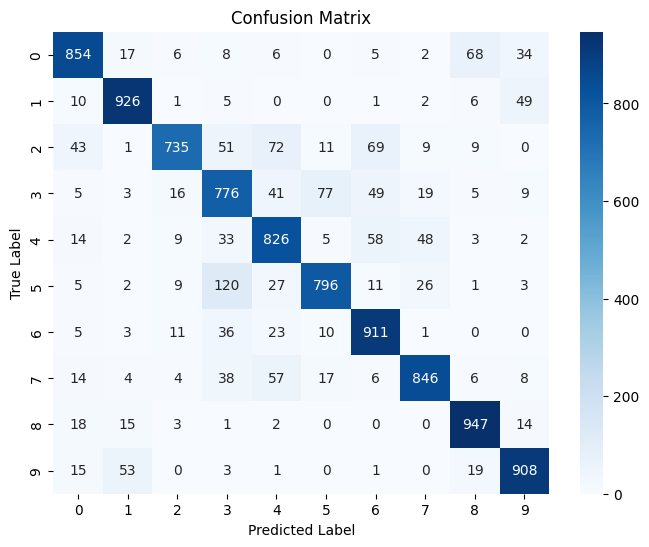

In [6]:
find_knn()

using SkLearn Library with Euclidean as the distance metric

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn1(k=10, X_train=X_train_knn_res, X_test=X_test_knn_res, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 84.83%
Confusion Matrix:
 [[861  19   6   7   5   0   5   2  65  30]
 [ 10 932   2   3   0   0   1   2   6  44]
 [ 56   3 735  47  70  10  63   9   7   0]
 [  8   7  19 788  39  68  46  14   3   8]
 [ 16   3  12  35 836   4  52  38   3   1]
 [  8   3  10 141  27 777  10  21   1   2]
 [  6   3  11  38  30  10 902   0   0   0]
 [ 18   6   7  44  66  24   7 819   5   4]
 [ 19  20   3   1   2   0   0   0 944  11]
 [ 17  68   0   4   1   0   1   0  20 889]]


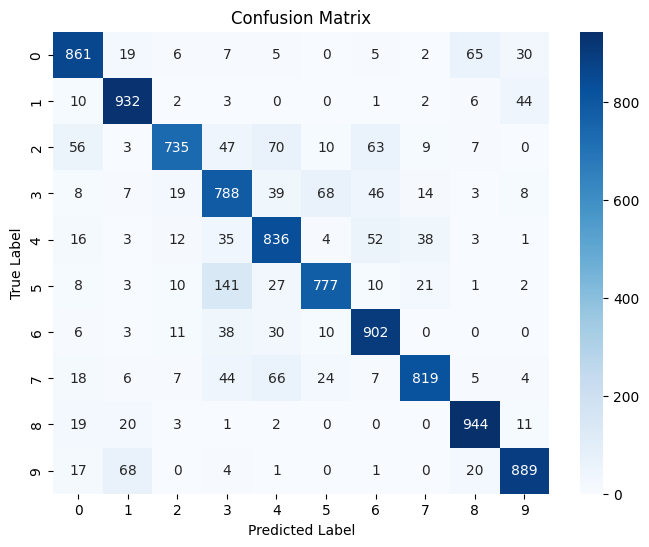

In [9]:
find_knn1()

using SkLearn Library with manhattan as the distance metric

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn2(k=10, X_train=X_train_knn_res, X_test=X_test_knn_res, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 84.73%
Confusion Matrix:
 [[870  17   5   6   4   0   6   3  62  27]
 [  8 940   2   2   0   0   2   1   6  39]
 [ 52   3 718  53  78   9  73   7   7   0]
 [  6   5  14 788  47  55  58  14   5   8]
 [ 12   2  12  32 839   4  67  28   3   1]
 [  6   1   8 146  30 774  13  19   0   3]
 [  6   4  14  36  28   8 904   0   0   0]
 [ 19   4   7  41  77  19   6 812   8   7]
 [ 28  19   3   1   2   0   0   0 938   9]
 [ 16  67   0   3   1   0   1   0  22 890]]


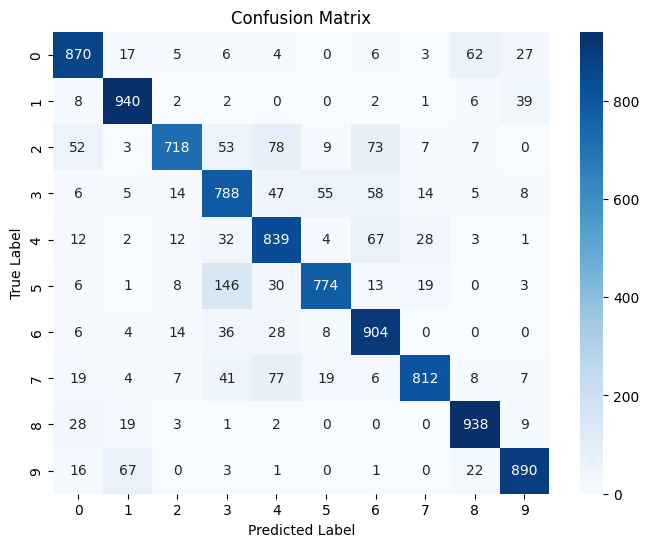

In [8]:
find_knn2()

using SkLearn Library with Canberra as the distance metric

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn3(k=10, X_train=X_train_knn_res, X_test=X_test_knn_res, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Canberra Distance")
    plt.show()




Accuracy: 85.67%
Confusion Matrix:
 [[867  17   7   9   2   3   5   2  45  43]
 [  1 942   0   1   1   0   0   3   2  50]
 [ 38   5 773  59  36  15  44  25   5   0]
 [  5   8  13 782  25 101  19  34   4   9]
 [ 13   2  21  44 734   4  46 128   4   4]
 [  1   1  10  96  19 827   4  38   0   4]
 [  4   4  12  64  17  11 884   1   1   2]
 [  5   7   2  23  15  22   1 917   0   8]
 [ 23  30   0   4   1   0   0   1 915  26]
 [ 10  51   0   2   0   0   1   2   8 926]]


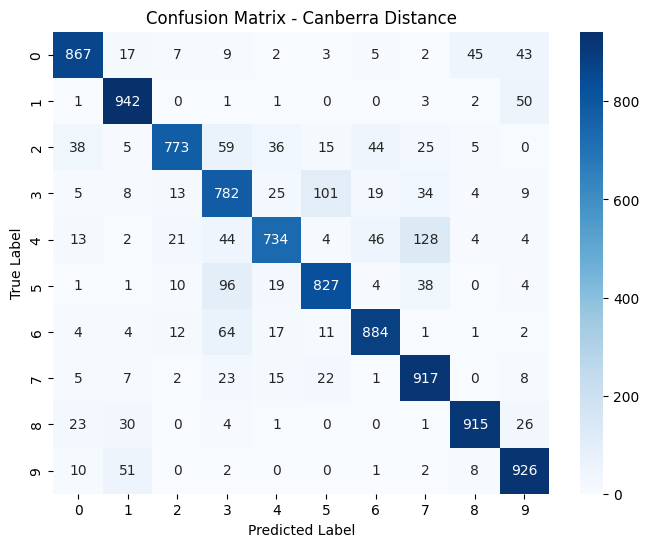

In [10]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn4(k=10, X_train=X_train_knn_res, X_test=X_test_knn_res, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Bray-Curtis Distance")
    plt.show()


Accuracy: 86.58%
Confusion Matrix:
 [[868  18   7   6   4   2   4   5  54  32]
 [  5 941   2   0   0   0   0   2   3  47]
 [ 35   3 779  45  56  15  43  16   7   1]
 [  5   6  12 783  19  95  42  25   4   9]
 [ 15   2  18  38 793   4  53  75   1   1]
 [  2   2   9  95  21 828   7  33   0   3]
 [  4   4  13  40  17   9 911   0   1   1]
 [ 12   4   7  21  32  20   4 896   2   2]
 [ 21  22   0   3   1   0   0   1 939  13]
 [ 10  54   0   3   0   0   1   0  12 920]]


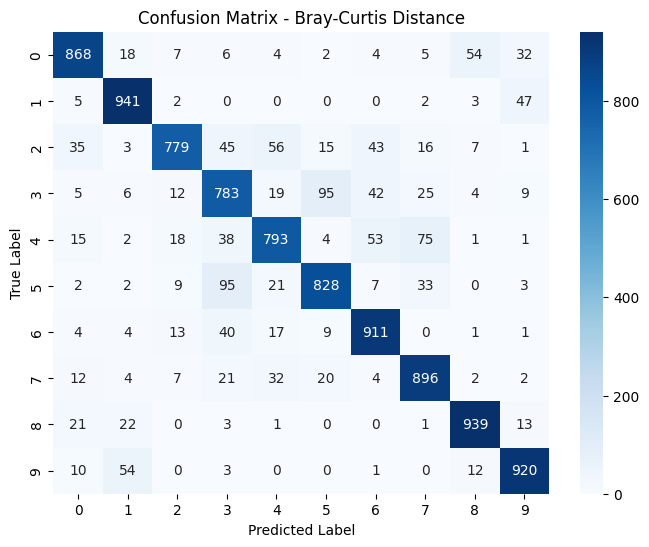

In [12]:
find_knn4()